# Survival Analysis: Time to Defibrillation vs. Patient Outcomes (Unbinned Logistic Regression)

This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) dataset to quantify how delay to first defibrillation affects patient outcomes.

Specifically, it uses **unbinned patient-level data** (one row per patient), computes **Time to First Defibrillation** from dispatch-call and first-shock timestamps, and fits two **logistic regression models** (`statsmodels.Logit`) over a constrained 0–20 minute window:

- **Predictor (X):** Time to First Defibrillation (minutes)
- **Outcome 1 (y):** Survival Status (1 = Survived, 0 = Dead)
- **Outcome 2 (y):** CPC Status (1 = Good CPC 1–2, 0 = Poor CPC 3–5)

Key outputs include:

- Logistic regression coefficient estimates, p-values, and model summaries
- **Odds Ratio** interpretation for each 1-minute delay (Survival and CPC)
- Fitted probability curves for Survival and CPC across 0–20 minutes
- A combined visualization comparing both modeled outcome curves

This provides a standard epidemiological estimate of the time–outcome relationship without time binning or exponential curve fitting.

# Need to install decryption Libraries

In [1]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl
import statsmodels.api as sm
from scipy.optimize import curve_fit

from pathlib import Path

# Get the password from env

In [3]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [4]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [5]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


In [6]:
print(df.columns.tolist())


['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

# Feature Engineering

In [ ]:
n_total = len(df)

# Age
age_mean = pd.to_numeric(df['Age'],
                         errors='coerce').mean()
age_sd = pd.to_numeric(df['Age'],
                       errors='coerce').std()

# Gender
male_pct = (df['Gender'].astype(str).str.contains('Male|M',
                                                  case=False,
                                                  na=False).sum() / n_total) * 100

# Ethnicity
df_race = df['Race'].astype(str)
chi_pct = (df_race.str.contains('Chinese',
                                case=False,
                                na=False).sum() / n_total) * 100
mal_pct = (df_race.str.contains('Malay',
                                case=False,
                                na=False).sum() / n_total) * 100
ind_pct = (df_race.str.contains('Indian',
                                case=False,
                                na=False).sum() / n_total) * 100
oth_pct = (df_race.str.contains('Other|Caucasian|Eurasian',
                                case=False,
                                na=False).sum() / n_total) * 100 

# Arrest Location
df_loc = df['Location Type'].astype(str)
res_pct = (df_loc.str.contains('Home|Residen|House',
                               case=False,
                               na=False).sum() / n_total) * 100
pub_pct = (df_loc.str.contains('Public|Commercial|Work|Street|Recreation|Transport',
                               case=False,
                               na=False).sum() / n_total) * 100

# Witness Status
df_wit = df['Arrest witnessed by'].astype(str)
wit_by_pct = (df_wit.str.contains('Bystander|Lay person|Family',
                                  case=False,
                                  na=False).sum() / n_total) * 100
wit_un_pct = (df_wit.str.contains('Unwitnessed|None|No',
                                  case=False,
                                  na=False).sum() / n_total) * 100

# Pre-EMS Interventions
cpr_pct = (df['Bystander CPR'].astype(str).str.contains('Yes',
                                                        case=False,
                                                        na=False).sum() / n_total) * 100
aed_pct = (df['Bystander AED applied'].astype(str).str.contains('Yes',
                                                                case=False,
                                                                na=False).sum() / n_total) * 100

# Rhythm 
df_rhythm = df['First arrest rhythm'].astype(str)
shock_pct = (df_rhythm.str.contains('VF|Ventricular Fibrillation|VT|pVT|Shockable',
                                    case=False,
                                    na=False,
                                    regex=True).sum() / n_total) * 100
non_pct = (df_rhythm.str.contains('Asystole|PEA|Pulseless|Non-Shockable',
                                  case=False,
                                  na=False,
                                  regex=True).sum() / n_total) * 100

# Creating Table Data Structure

In [8]:
table_data = [
    ["Demographics", ""],
    ["Total Patients (n)", f"{n_total:,}"],
    ["Age (Mean ± SD)", f"{age_mean:.1f} ± {age_sd:.1f}"],
    ["Gender (Male %)", f"{male_pct:.1f}%"],
    ["Ethnicity (%)", ""],
    ["    Chinese", f"{chi_pct:.1f}%"],
    ["    Malay", f"{mal_pct:.1f}%"],
    ["    Indian", f"{ind_pct:.1f}%"],
    ["    Others", f"{oth_pct:.1f}%"],
    
    ["Arrest Context & Location", ""],
    ["Arrest Location (%)", ""],
    ["    Residential / Home", f"{res_pct:.1f}%"],
    ["    Public / Commercial", f"{pub_pct:.1f}%"],
    
    ["Witness Status (%)", ""],
    ["    Bystander Witnessed", f"{wit_by_pct:.1f}%"],
    ["    Unwitnessed", f"{wit_un_pct:.1f}%"],
    
    ["Pre-EMS Interventions & Physiology", ""],
    ["Bystander CPR (%)", f"{cpr_pct:.1f}%"],
    ["Bystander AED Applied (%)", f"{aed_pct:.1f}%"],
    
    ["Initial Rhythm (%)", ""],
    ["    Shockable (VF/pVT)", f"{shock_pct:.1f}%"],
    ["    Non-Shockable (Asystole/PEA)", f"{non_pct:.1f}%"]
]

# Plotting out the table

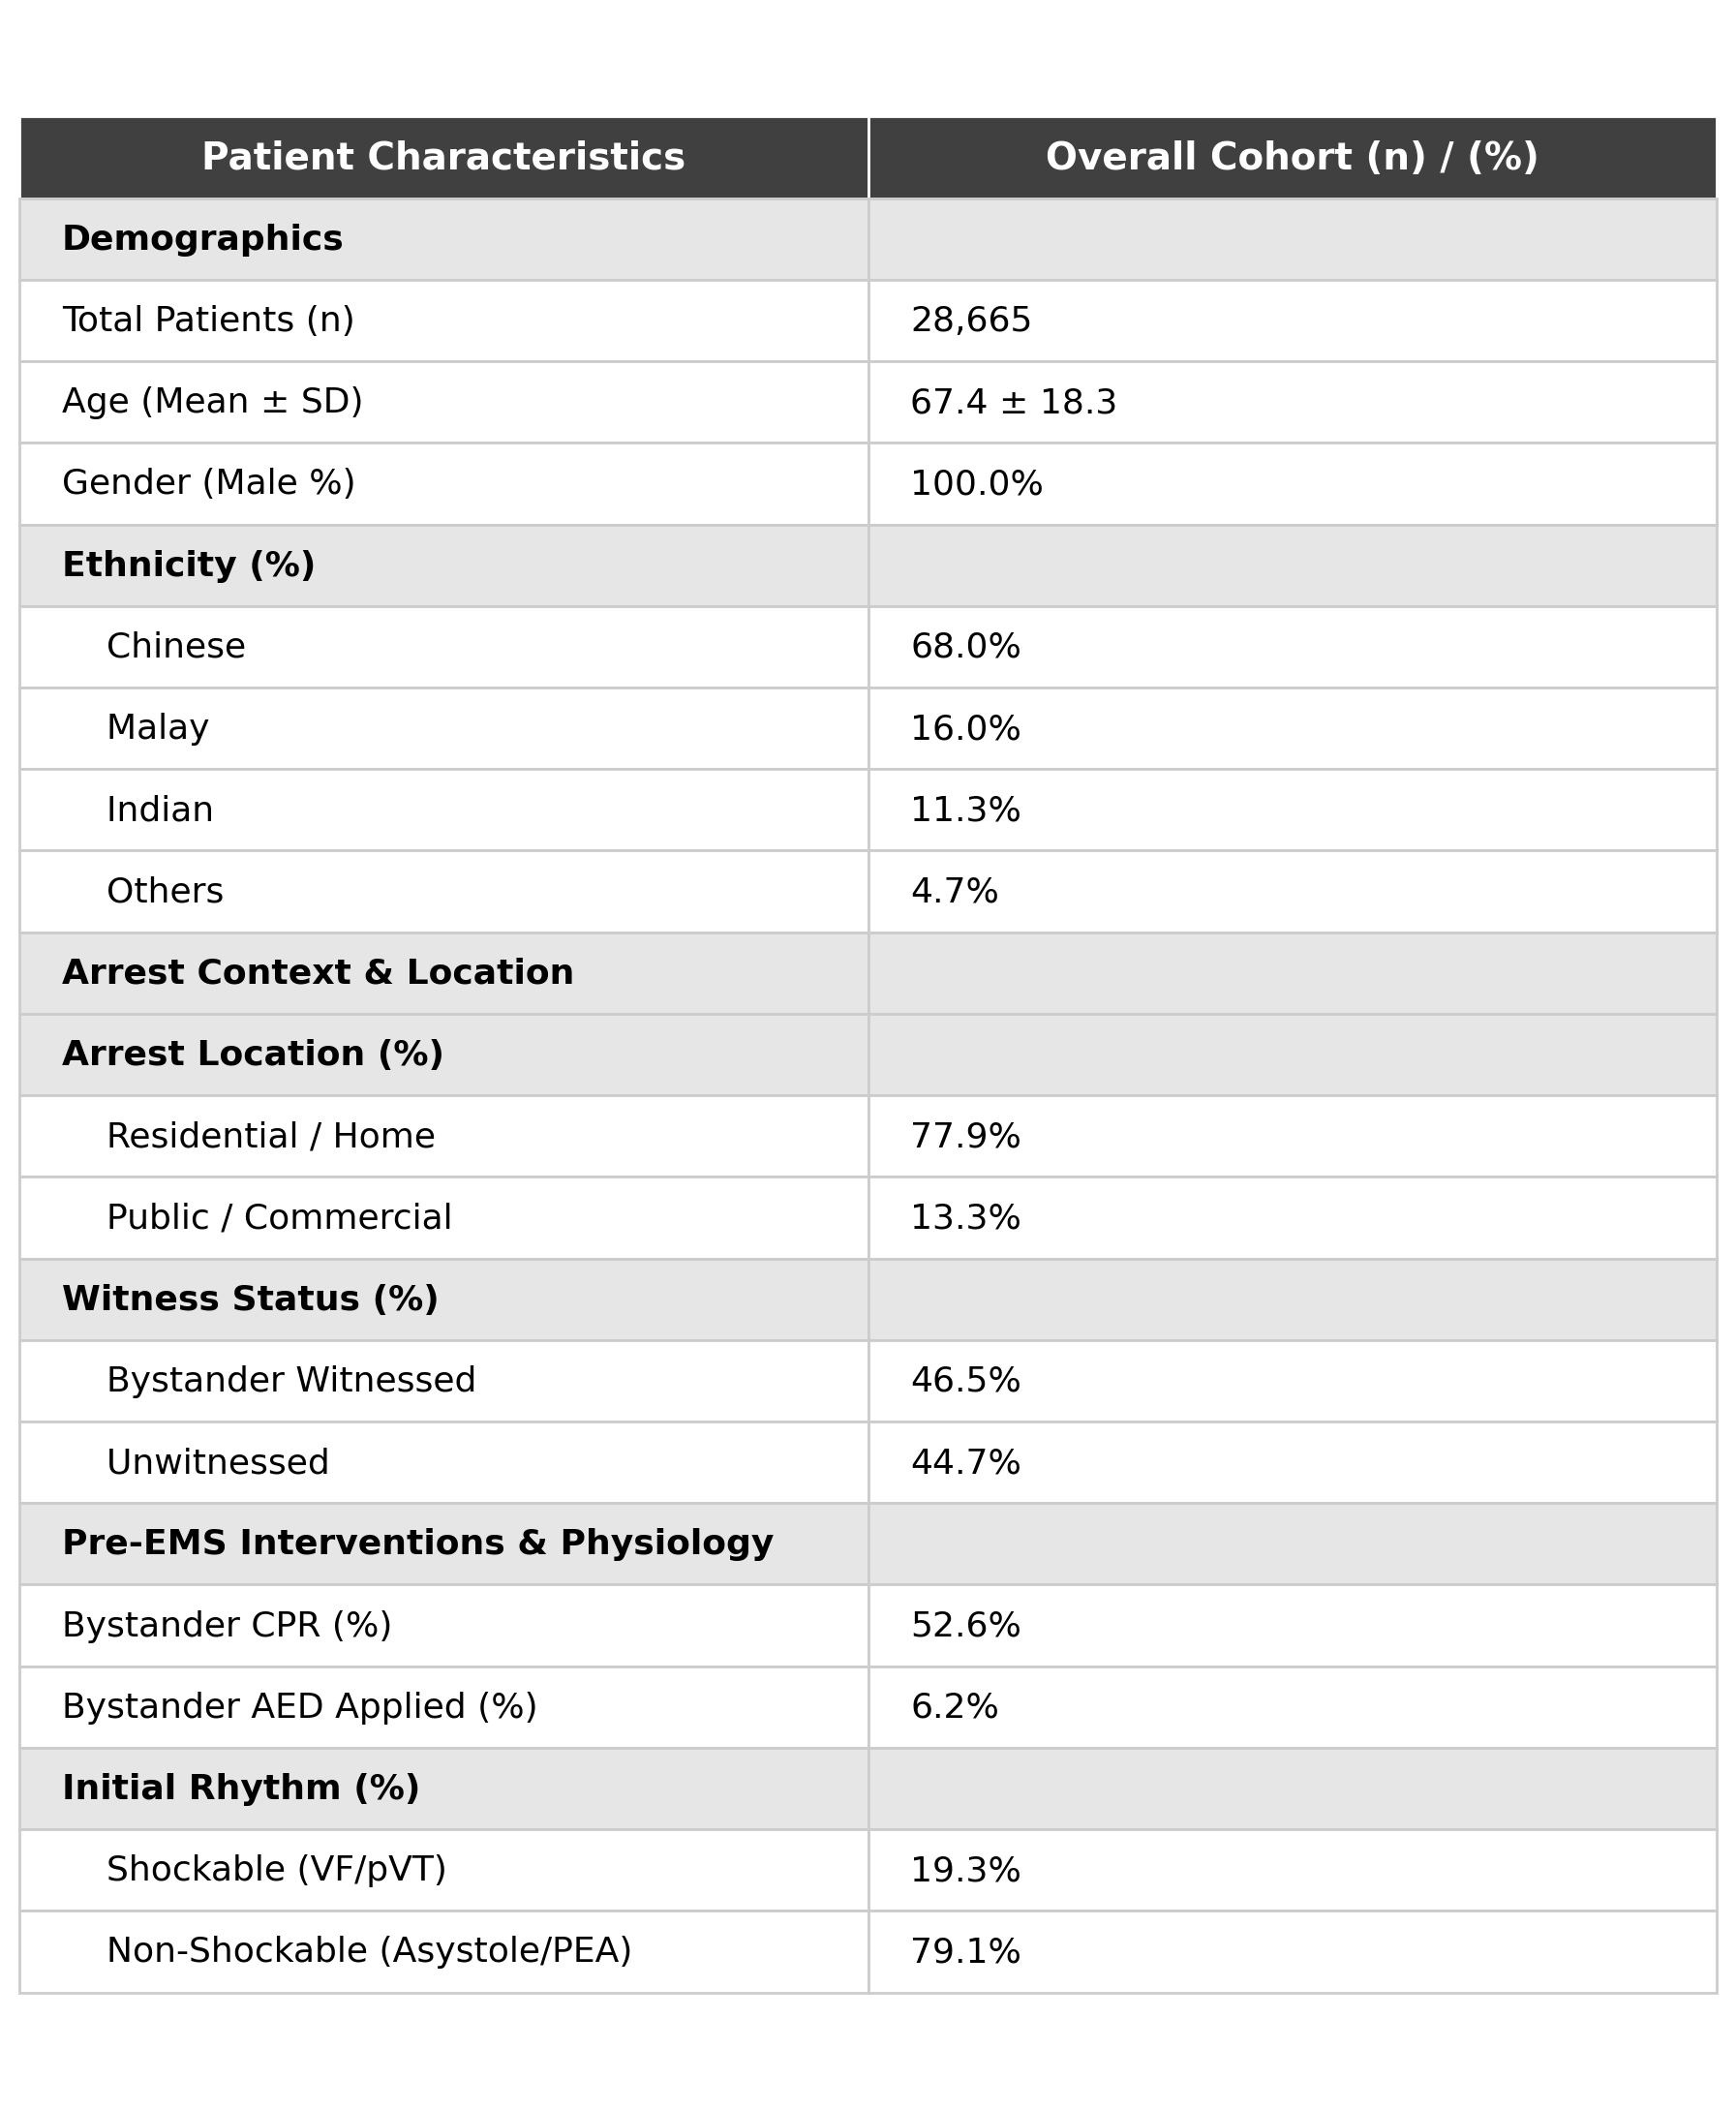

In [22]:
fig, ax = plt.subplots(figsize=(9, 11),
                       dpi=200) 
ax.axis('off')

# Create the table
tbl = ax.table(cellText=table_data, 
               colLabels=["Patient Characteristics", "Overall Cohort (n) / (%)"], 
               loc='center', 
               cellLoc='left')

# ax.set_title(
#     "Table 1: Baseline Characteristics of OHCA Cohort",
#     fontsize=16,
#     color='black',
#     pad=1
# )

# Styling
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1.2, 2.0)

# Format headers and sub-headers
for (i, j), cell in tbl.get_celld().items():
    cell.PAD = 0.05
    cell.set_edgecolor('#cccccc') # Light gray borders
    
    # Top Header Row (Dark Gray Background, White Text)
    if i == 0:
        cell.set_text_props(weight='bold', color='white', size=14)
        cell.set_facecolor('#404040') 
        cell.set_edgecolor('white')
        
    # Sub-category Headers (Light Gray Background, Black Text)
    elif table_data[i-1][1] == "":
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#e6e6e6')
        
    # Standard Data Rows (White Background, Black Text)
    else:
        cell.set_facecolor('#ffffff')
        cell.set_text_props(color='black')

plt.tight_layout()
plt.show()